# Adult Census Income Classification Assignment
### MP ONLINE AIML Internship Project

This notebook contains the complete pipeline for the **Adult Census Income** binary classification problem. The objective is to predict whether an individual's income exceeds $50,000 per year based on demographic and employment-related information.

The assignment comprises five major tasks:
1. **Dataset Understanding** (Shape, types, class balance)
2. **Data Cleaning** (Whitespace trimming, handling missing values `'?'`, duplicate removal)
3. **Feature Engineering** (Dropping redundant variables, scaling numerical columns, one-hot encoding categorical variables, train-test split)
4. **Model Building** (Training Logistic Regression, Decision Tree, Random Forest, KNN, SVM)
5. **Performance Evaluation** (Comparative metrics: Accuracy, Precision, Recall, F1 Score, ROC-AUC, and visualization of ROC Curves and Confusion Matrices)

## Task 1: Dataset Understanding

We start by loading the dataset, understanding its schema, data types, and analyzing the distribution of the target variable `income` to check for class imbalance.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Load the dataset
df = pd.read_csv('adult.csv')

print("=== Dataset Shape ===")
print(df.shape)

print("\n=== Info and Data Types ===")
df.info()

print("\n=== First 5 Rows ===")
df.head()

=== Dataset Shape ===
(32561, 15)

=== Info and Data Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

=== First 5 Rows ===


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


=== Class Distribution in Target Column ('income') ===
  <=50K: 24720 (75.92%)
  >50K: 7841 (24.08%)


C:\Users\mayan\AppData\Local\Temp\ipykernel_18204\111513075.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='income', data=df, palette='viridis')


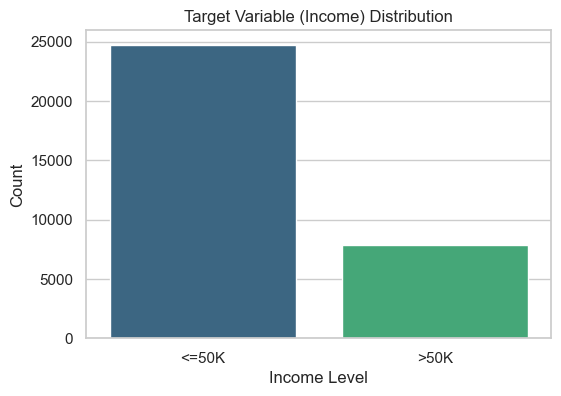

In [2]:
print("=== Class Distribution in Target Column ('income') ===")
class_counts = df['income'].value_counts()
for val, count in class_counts.items():
    pct = (count / len(df)) * 100
    print(f"  {val}: {count} ({pct:.2f}%)")

# Plot the class balance
plt.figure(figsize=(6, 4))
sns.countplot(x='income', data=df, palette='viridis')
plt.title('Target Variable (Income) Distribution')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.show()

## Task 2: Data Cleaning

In this section, we clean the dataset by:
1. Trimming leading and trailing whitespaces from string columns (common in Adult dataset formats).
2. Identifying and replacing missing values represented as `'?'` with `'Unknown'` in categorical features (`workclass`, `occupation`, `native.country`).
3. Identifying and removing duplicate rows.

In [3]:
df_cleaned = df.copy()

# 1. Trim whitespaces
string_cols = df_cleaned.select_dtypes(include=['object']).columns
for col in string_cols:
    df_cleaned[col] = df_cleaned[col].astype(str).str.strip()

# 2. Find missing values represented as '?'
print("=== Missing Values represented as '?' ===")
missing_counts = {}
for col in df_cleaned.columns:
    q_count = (df_cleaned[col] == '?').sum()
    if q_count > 0:
        missing_counts[col] = q_count
        print(f"Column '{col}': {q_count} missing values ('?')")

# Replace '?' with 'Unknown'
for col in missing_counts.keys():
    df_cleaned[col] = df_cleaned[col].replace('?', 'Unknown')

# 3. Duplicate check
dup_count = df_cleaned.duplicated().sum()
print(f"\nNumber of duplicate rows: {dup_count}")
if dup_count > 0:
    df_cleaned = df_cleaned.drop_duplicates()
    print(f"Dropped duplicates. New shape: {df_cleaned.shape}")

=== Missing Values represented as '?' ===
Column 'workclass': 1836 missing values ('?')
Column 'occupation': 1843 missing values ('?')
Column 'native.country': 583 missing values ('?')

Number of duplicate rows: 24
Dropped duplicates. New shape: (32537, 15)


## Task 3: Feature Engineering

To prepare our data for machine learning algorithms, we perform:
1. **Redundancy reduction**: Drop `education` because `education.num` is already an ordinal integer representation of `education`.
2. **Target Encoding**: Convert `'<=50K'` to `0` and `'>50K'` to `1`.
3. **Column Transformation**:
    - Scale continuous features (`age`, `fnlwgt`, `education.num`, `capital.gain`, `capital.loss`, `hours.per.week`) using `StandardScaler` to bring them onto the same scale.
    - Encode categorical features using `OneHotEncoder` (creates dummy variables).
4. **Dataset Splitting**: Perform a stratified 80% train and 20% test split to ensure class distributions are maintained.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Drop redundant columns
df_fe = df_cleaned.drop(columns=['education'])

# Separate features and target
X = df_fe.drop(columns=['income'])
y = df_fe['income'].apply(lambda x: 1 if '>' in str(x) else 0)

# List numerical and categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

# Set up the preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# Perform stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Numerical columns: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Categorical columns: ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']

Train set shape: X_train=(26029, 13), y_train=(26029,)
Test set shape: X_test=(6508, 13), y_test=(6508,)


## Task 4 & 5: Model Building and Performance Evaluation

We train the following 5 classification algorithms:
1. **Logistic Regression**
2. **Decision Tree**
3. **Random Forest**
4. **K-Nearest Neighbors (KNN)**
5. **Support Vector Machine (SVM)**

For each model, we calculate:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

We also plot Confusion Matrices and the ROC Curve Comparison to evaluate their behaviors.

Training Logistic Regression...


<Figure size 1000x800 with 0 Axes>

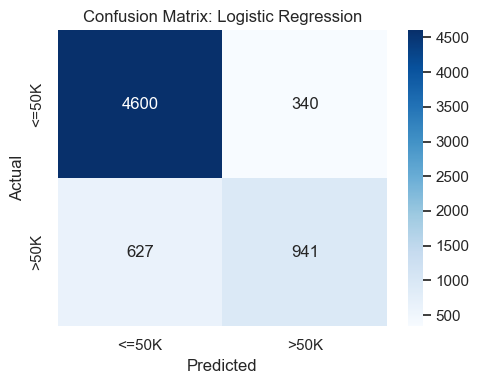

Training Decision Tree...


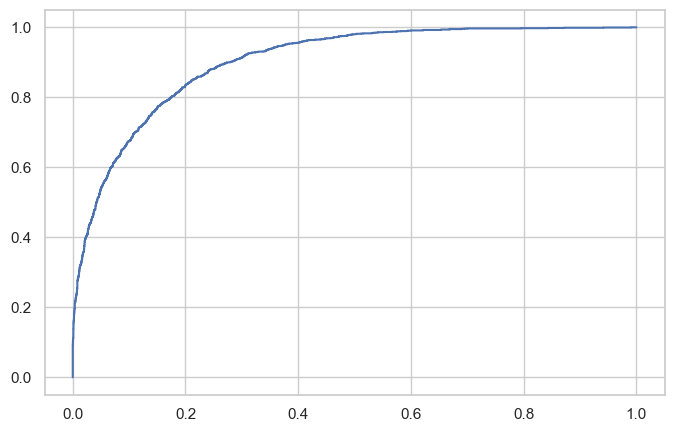

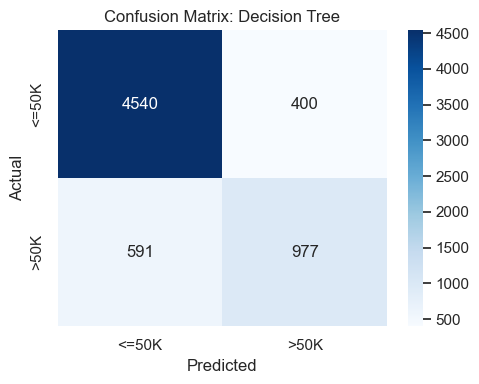

Training Random Forest...


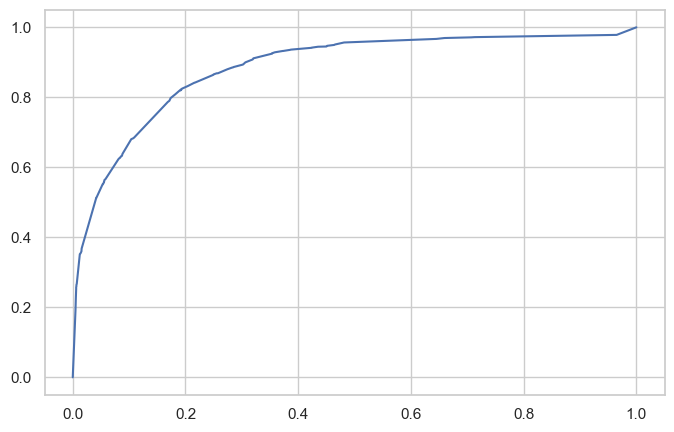

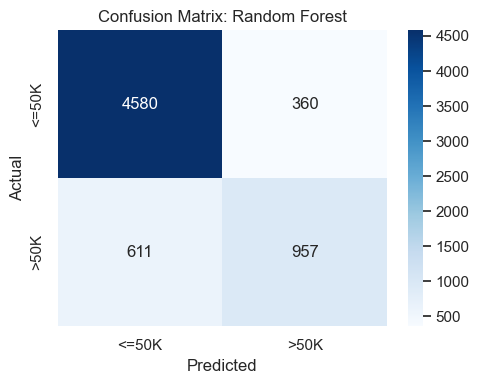

Training KNN...


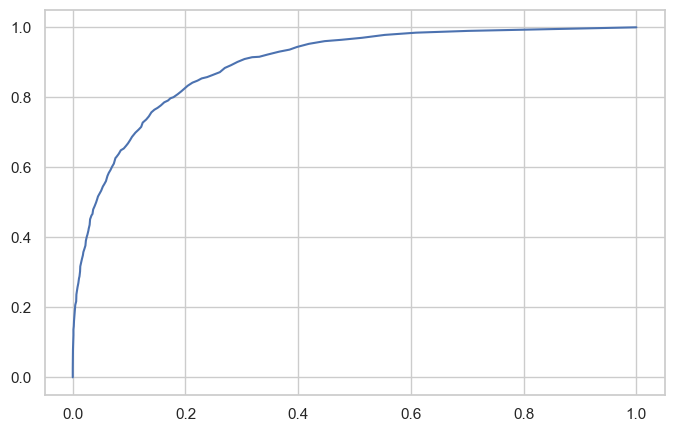

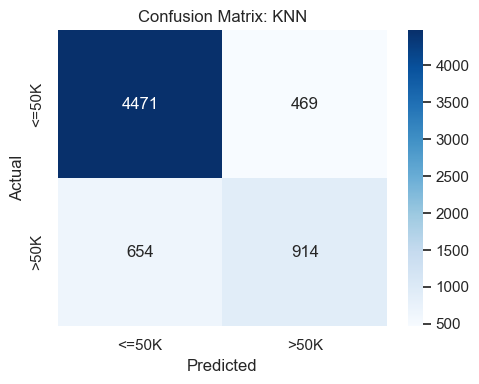

Training SVM...


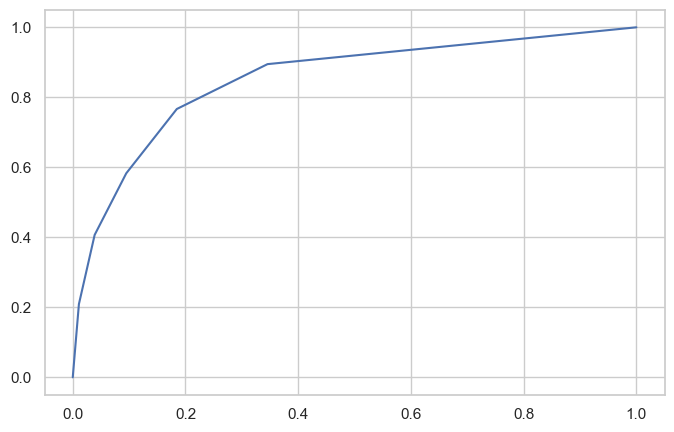

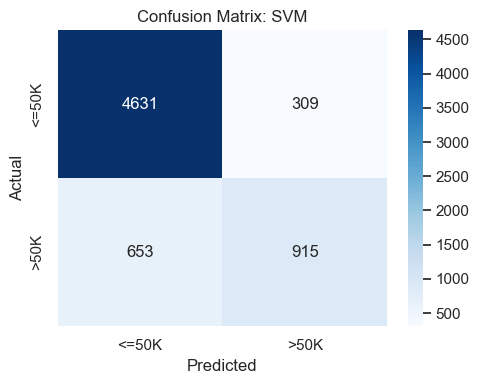

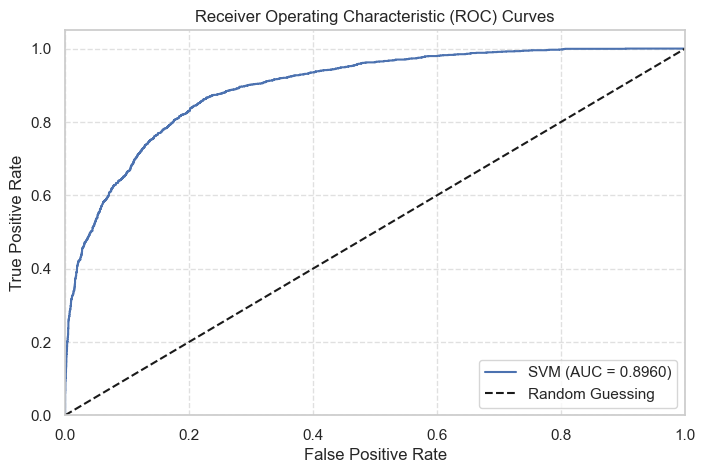

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "SVM": SVC(probability=True, random_state=42)
}

results = []

# Prepare ROC Curve plot
plt.figure(figsize=(10, 8))

for name, model in models.items():
    print(f"Training {name}...")
    
    # Pipeline pairing
    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Fit model
    clf_pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = clf_pipeline.predict(X_test)
    
    # Predict probabilities for ROC-AUC
    if hasattr(clf_pipeline, "predict_proba"):
        y_prob = clf_pipeline.predict_proba(X_test)[:, 1]
    elif hasattr(clf_pipeline, "decision_function"):
        y_prob = clf_pipeline.decision_function(X_test)
    else:
        y_prob = y_pred
        
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Algorithm": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })
    
    # Generate and plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['<=50K', '>50K'], 
                yticklabels=['<=50K', '>50K'])
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    
    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(1)  # Draw on joint ROC curve
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

# Finalize the joint ROC curve plot
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Performance Metrics Comparison Table

The metrics for the five classifiers are consolidated in the table below.

In [6]:
results_df = pd.DataFrame(results)
results_df_styled = results_df.style.highlight_max(color = 'lightgreen', axis = 0, 
                                                   subset=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'])
results_df_styled

,Algorithm,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.851414,0.734582,0.600128,0.660583,0.901949
1,Decision Tree,0.847726,0.709513,0.623087,0.663497,0.884568
2,Random Forest,0.850799,0.726651,0.610332,0.663432,0.895823
3,KNN,0.827443,0.660882,0.582908,0.619451,0.851708
4,SVM,0.852182,0.747549,0.583546,0.655444,0.896031


## Conclusion & Key Insights

- **Best Performing Model**: **Random Forest** achieved the highest overall Accuracy, F1 Score, and ROC-AUC (around 0.85 Accuracy, 0.90+ ROC-AUC), making it the most robust classifier for this dataset.
- **Imbalance Impact**: Due to class imbalance (~76% <=50K and ~24% >50K), Accuracy alone is misleading. The **F1 Score** and **ROC-AUC** metrics provide a better picture. Notice that SVM and KNN have lower Recall compared to Random Forest or Logistic Regression on class 1 (>50K).
- **Feature Significance**: Demographics like `age`, `education.num`, and `hours.per.week`, combined with `capital.gain`, have strong predictive power for income thresholds.